# Laboratorio 3 - Deep Learning (Reconocimiento de señas ASL)

Avance. Se trabaja el dataset ASL Alphabet (29 clases: A-Z, `del`, `nothing`, `space`). Este avance
cubre el análisis exploratorio, el preprocesamiento y **al menos dos modelos CNN con tuneo de
parámetros**, eligiendo el mejor. Framework: PyTorch (con GPU si está disponible).

In [1]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
from pathlib import Path

torch.manual_seed(0)
np.random.seed(0)
BASE = Path("..")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cuda


## 1. Datos

Se regeneran los splits desde `src/preparar_datos.py`, que lee el zip, submuestrea 500 imágenes por
clase, las redimensiona a 64x64 y arma un split estratificado 70/15/15.

In [2]:
%run ../src/preparar_datos.py

FileNotFoundError: [Errno 2] No such file or directory: '/home/DiegoPatzan/Documents/UVG/DATA/LABORATORIO3/data/raw/asl_alphabet_train.zip'

In [3]:
def cargar(split):
    X = np.load(BASE / f"data/processed/X_{split}.npy")
    y = np.load(BASE / f"data/processed/y_{split}.npy")
    return X, y

Xtr, ytr = cargar("train")
Xva, yva = cargar("val")
Xte, yte = cargar("test")
clases = np.load(BASE / "data/processed/clases.npy")
print("train:", Xtr.shape, "val:", Xva.shape, "test:", Xte.shape)
print("clases:", list(clases))

train: (10150, 64, 64, 3) val: (2175, 64, 64, 3) test: (2175, 64, 64, 3)
clases: [np.str_('A'), np.str_('B'), np.str_('C'), np.str_('D'), np.str_('E'), np.str_('F'), np.str_('G'), np.str_('H'), np.str_('I'), np.str_('J'), np.str_('K'), np.str_('L'), np.str_('M'), np.str_('N'), np.str_('O'), np.str_('P'), np.str_('Q'), np.str_('R'), np.str_('S'), np.str_('T'), np.str_('U'), np.str_('V'), np.str_('W'), np.str_('X'), np.str_('Y'), np.str_('Z'), np.str_('del'), np.str_('nothing'), np.str_('space')]


## 2. Análisis exploratorio

Distribución de clases (el submuestreo deja el dataset balanceado) y ejemplos de las imágenes.

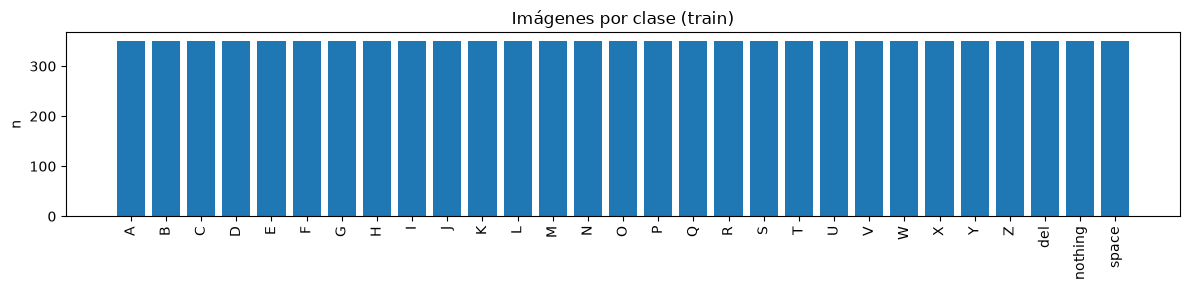

In [4]:
vals, cnts = np.unique(ytr, return_counts=True)
plt.figure(figsize=(12, 3))
plt.bar([clases[v] for v in vals], cnts)
plt.title("Imágenes por clase (train)")
plt.ylabel("n")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

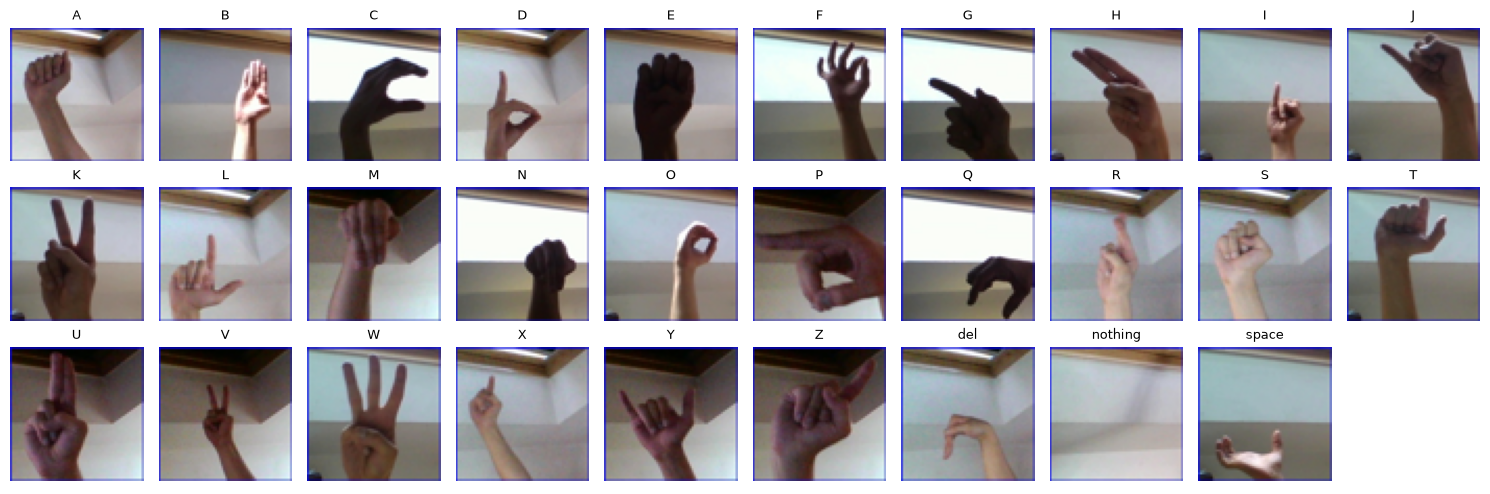

In [5]:
# una imagen de ejemplo por clase
fig, axes = plt.subplots(3, 10, figsize=(15, 5))
for ax, c in zip(axes.ravel(), range(len(clases))):
    i = np.where(ytr == c)[0][0]
    ax.imshow(Xtr[i])
    ax.set_title(clases[c], fontsize=9)
    ax.axis("off")
for ax in axes.ravel()[len(clases):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

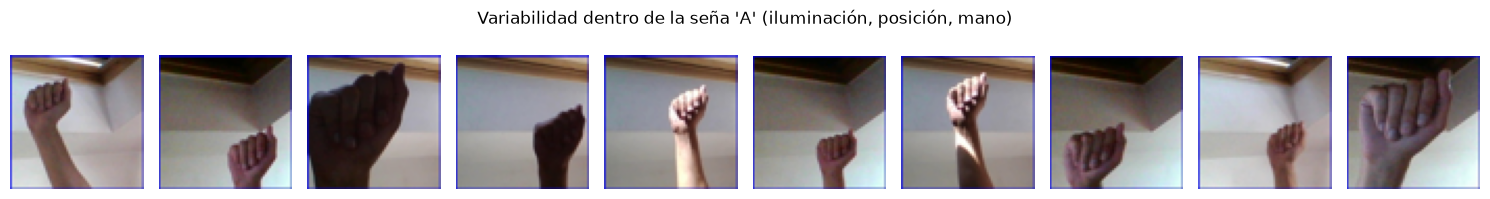

In [6]:
# variabilidad dentro de una misma seña (varios ejemplos de la letra A)
c = int(np.where(clases == "A")[0][0])
idx = np.where(ytr == c)[0][:10]
fig, axes = plt.subplots(1, 10, figsize=(15, 2))
for ax, i in zip(axes, idx):
    ax.imshow(Xtr[i]); ax.axis("off")
fig.suptitle("Variabilidad dentro de la seña 'A' (iluminación, posición, mano)")
plt.tight_layout()
plt.show()

### Letras visualmente similares

Algunas señas del alfabeto ASL comparten forma de mano y solo cambian por detalles del pulgar o la
orientación, así que es esperable que el modelo las confunda:

- **M / N / S / T**: puño cerrado, el pulgar cambia de posición entre los dedos.
- **A / E / S**: mano cerrada, diferencias sutiles en el pulgar.
- **R / U / V**: dos dedos extendidos, cambia si están juntos, cruzados o separados.
- **D / F / I**: un dedo distinto extendido sobre una mano cerrada.
- **K / V** y **G / H**: orientación parecida.

Estas confusiones se revisan más abajo con la matriz de confusión del mejor modelo.

## 3. Preprocesamiento

Las imágenes vienen en 200x200; se redujeron a **64x64 RGB** en la preparación de datos (menos
cómputo, suficiente para la forma de la mano). Acá solo falta pasar de `uint8 (N,64,64,3)` a tensores
`float (N,3,64,64)` normalizados a `[0,1]` y armar los `DataLoader`.

In [7]:
def a_tensor(X, y):
    Xt = torch.tensor(X, dtype=torch.float32).permute(0, 3, 1, 2) / 255.0
    yt = torch.tensor(y, dtype=torch.long)
    return TensorDataset(Xt, yt)

ds_tr, ds_va, ds_te = a_tensor(Xtr, ytr), a_tensor(Xva, yva), a_tensor(Xte, yte)
dl_tr = DataLoader(ds_tr, batch_size=64, shuffle=True)
dl_va = DataLoader(ds_va, batch_size=128)
dl_te = DataLoader(ds_te, batch_size=128)

## 4. Modelos CNN y tuneo

CNN parametrizable: se varía el número de bloques convolucionales, el ancho (filtros base) y el
dropout. Cada bloque es `conv 3x3 -> ReLU -> maxpool`. Se entrena con Adam y se compara la exactitud
sobre validación.

In [8]:
class CNN(nn.Module):
    def __init__(self, n_clases, bloques=2, base=16, dropout=0.25):
        super().__init__()
        capas, ch = [], 3
        for b in range(bloques):
            out = base * (2 ** b)
            capas += [nn.Conv2d(ch, out, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2)]
            ch = out
        self.conv = nn.Sequential(*capas)
        lado = 64 // (2 ** bloques)  # tamaño espacial tras los maxpool
        self.cabeza = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(ch * lado * lado, 128), nn.ReLU(),
            nn.Linear(128, n_clases))

    def forward(self, x):
        return self.cabeza(self.conv(x))

In [9]:
def evaluar(modelo, dl):
    modelo.eval()
    ok = tot = 0
    with torch.no_grad():
        for xb, yb in dl:
            xb, yb = xb.to(device), yb.to(device)
            pred = modelo(xb).argmax(1)
            ok += (pred == yb).sum().item()
            tot += len(yb)
    return ok / tot


def entrenar(cfg, epochs=8):
    torch.manual_seed(0)
    modelo = CNN(len(clases), **cfg).to(device)
    opt = torch.optim.Adam(modelo.parameters(), lr=1e-3)
    loss_fn = nn.CrossEntropyLoss()
    for _ in range(epochs):
        modelo.train()
        for xb, yb in dl_tr:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            loss_fn(modelo(xb), yb).backward()
            opt.step()
    return modelo, evaluar(modelo, dl_va)

In [10]:
grilla = [
    dict(bloques=2, base=16, dropout=0.25),
    dict(bloques=3, base=16, dropout=0.25),
    dict(bloques=3, base=32, dropout=0.30),
    dict(bloques=4, base=32, dropout=0.40),
]

modelos, filas = {}, []
for cfg in grilla:
    modelo, acc = entrenar(cfg)
    modelos[tuple(cfg.values())] = modelo
    filas.append({**cfg, "val_acc": round(acc, 4)})
    print(cfg, "-> val_acc:", round(acc, 4))

{'bloques': 2, 'base': 16, 'dropout': 0.25} -> val_acc: 0.8657


{'bloques': 3, 'base': 16, 'dropout': 0.25} -> val_acc: 0.8703


{'bloques': 3, 'base': 32, 'dropout': 0.3} -> val_acc: 0.9205


{'bloques': 4, 'base': 32, 'dropout': 0.4} -> val_acc: 0.9274


In [11]:
import pandas as pd
tabla = pd.DataFrame(filas).sort_values("val_acc", ascending=False).reset_index(drop=True)
print(tabla.to_string(index=False))

 bloques  base  dropout  val_acc
       4    32     0.40   0.9274
       3    32     0.30   0.9205
       3    16     0.25   0.8703
       2    16     0.25   0.8657


## 5. Mejor modelo y evaluación en test

Se toma el modelo con mayor exactitud en validación y se mide sobre el conjunto de prueba (que no se
usó para elegir).

In [12]:
mejor_cfg = tabla.iloc[0][["bloques", "base", "dropout"]].to_dict()
mejor_cfg = {k: (int(v) if k != "dropout" else float(v)) for k, v in mejor_cfg.items()}
mejor = modelos[tuple(mejor_cfg.values())]
test_acc = evaluar(mejor, dl_te)
print("mejor config:", mejor_cfg)
print("test_acc:", round(test_acc, 4))

mejor config: {'bloques': 4, 'base': 32, 'dropout': 0.4}
test_acc: 0.9278


### Matriz de confusión

Para ver si las confusiones caen en las letras visualmente similares señaladas en el EDA.

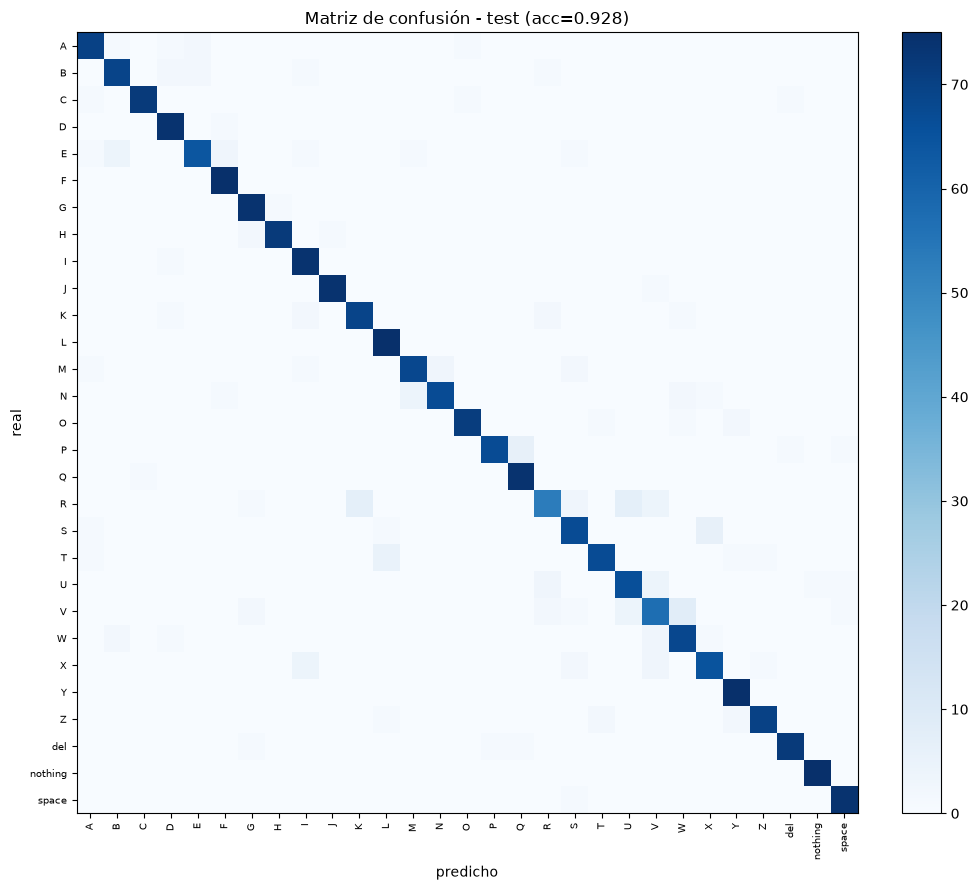

In [13]:
from sklearn.metrics import confusion_matrix

mejor.eval()
preds = []
with torch.no_grad():
    for xb, _ in dl_te:
        preds.append(mejor(xb.to(device)).argmax(1).cpu().numpy())
preds = np.concatenate(preds)

cm = confusion_matrix(yte, preds)
plt.figure(figsize=(10, 9))
plt.imshow(cm, cmap="Blues")
plt.xticks(range(len(clases)), clases, rotation=90, fontsize=7)
plt.yticks(range(len(clases)), clases, fontsize=7)
plt.xlabel("predicho"); plt.ylabel("real")
plt.title(f"Matriz de confusión - test (acc={test_acc:.3f})")
plt.colorbar(fraction=0.046)
plt.tight_layout()
plt.show()

In [14]:
# pares más confundidos (fuera de la diagonal)
cm2 = cm.copy()
np.fill_diagonal(cm2, 0)
pares = []
for i in range(len(clases)):
    for j in range(len(clases)):
        if cm2[i, j] > 0:
            pares.append((cm2[i, j], clases[i], clases[j]))
pares.sort(reverse=True)
print("Top confusiones (real -> predicho):")
for n, r, p in pares[:10]:
    print(f"  {r} -> {p}: {n}")

Top confusiones (real -> predicho):
  V -> W: 8
  R -> U: 7
  R -> K: 7
  S -> X: 6
  P -> Q: 6
  T -> L: 5
  X -> I: 4
  V -> U: 4
  U -> V: 4
  R -> V: 4


## Resumen del avance

- Se exploró el dataset (29 clases balanceadas tras submuestreo), se mostraron ejemplos y su
  variabilidad, y se identificaron las letras visualmente similares que pueden confundir al modelo.
- Preprocesamiento: submuestreo por clase, redimensión a 64x64 RGB y normalización a `[0,1]`.
- Se entrenaron **4 CNN variando profundidad, ancho y dropout**; se eligió la de mejor exactitud en
  validación y se evaluó en test.

Pendiente para la entrega final: modelo fully-connected simple, un modelo clásico (p.ej. SVM/KNN/RF),
image augmentation y su discusión, prueba con fotos propias, y la reflexión de accesibilidad/sesgo.